# 个人作业1：桌游复杂度与玩家评分的量化关系分析
## —— 基于 BoardGameGeek 数据
### 大数据处理技术课程 — 2025-2026第二学期
**授课教师：周孟莹** | **数据集：BGG BoardGameGeek (TidyTuesday 2019)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

print('环境就绪')

环境就绪


In [2]:
# 数据加载与清洗
df = pd.read_csv('data/bgg_board_games.csv')
print(f'原始数据：{df.shape[0]:,} 行 × {df.shape[1]} 列')

# 过滤：评分人数 >= 30，有效年份，有效评分范围
df = df[df['users_rated'] >= 30]
df = df[df['year_published'] > 0]
df = df[df['year_published'] <= 2026]
df = df[(df['average_rating'] >= 1) & (df['average_rating'] <= 10)]
df = df[df['playing_time'] > 0]

# 填充缺失值
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna('Unknown')

# 衍生特征
df['log_users_rated'] = np.log1p(df['users_rated'])
df['mechanics_count'] = df['mechanic'].fillna('').str.split(',').apply(
    lambda x: len([i for i in x if i.strip() != ''])
)
time_bins = [0, 30, 60, 120, 99999]
time_labels = ['<30分钟', '30-60分钟', '60-120分钟', '>120分钟']
df['time_bin'] = pd.cut(df['playing_time'], bins=time_bins, labels=time_labels)

year_bins = [1900, 1980, 1995, 2005, 2015, 2026]
year_labels = ['1980以前', '1980-1995', '1995-2005', '2005-2015', '2015以后']
df['era'] = pd.cut(df['year_published'], bins=year_bins, labels=year_labels)

print(f'清洗后：{len(df):,} 款游戏，年份 {df["year_published"].min():.0f}-{df["year_published"].max():.0f}')
print(f'缺失值：{df.isnull().sum().sum()}')
df[['name', 'year_published', 'average_rating', 'users_rated', 'playing_time']].head()

原始数据：10,532 行 × 22 列
清洗后：10,182 款游戏，年份 1950-2016
缺失值：0


,name,year_published,average_rating,users_rated,playing_time
0,Die Macher,1986,7.66508,4498,240
1,Dragonmaster,1981,6.60815,478,30
2,Samurai,1998,7.44119,12019,60
3,Tal der Könige,1992,6.60675,314,60
4,Acquire,1964,7.35830,15195,90


### 数据字典
| 列名 | 说明 |
|------|------|
| average_rating | 平均评分 (1-10) |
| users_rated | 评分人数 |
| playing_time | 游戏时长（分钟）|
| mechanic | 游戏机制标签 |
| category | 游戏类别 |
| year_published | 出版年份 |

## 探索性数据分析

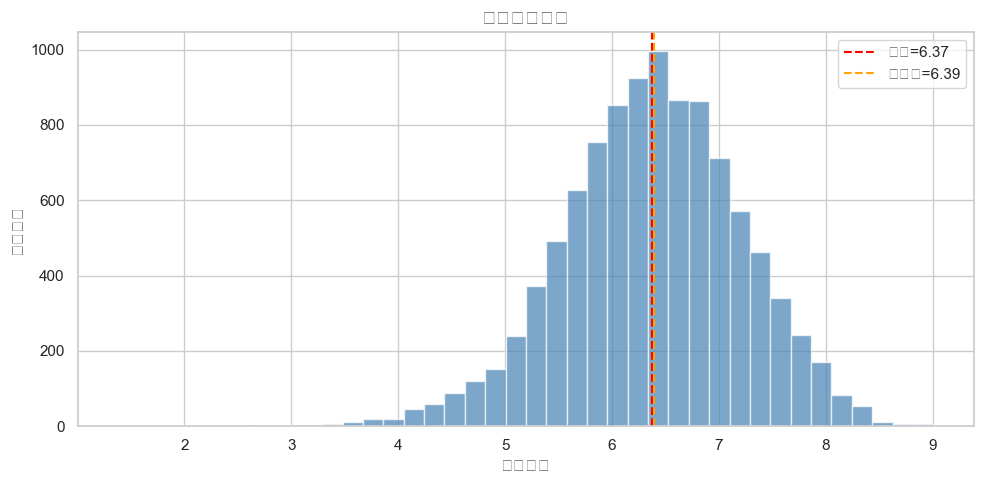

偏度=-0.30，峰度=0.50


In [3]:
# EDA 1：评分分布
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['average_rating'], bins=40, edgecolor='white', color='steelblue', alpha=0.7)
ax.axvline(df['average_rating'].mean(), color='red', linestyle='--', label=f'均值={df["average_rating"].mean():.2f}')
ax.axvline(df['average_rating'].median(), color='orange', linestyle='--', label=f'中位数={df["average_rating"].median():.2f}')
ax.set_title('桌游评分分布', fontsize=14, fontweight='bold')
ax.set_xlabel('平均评分')
ax.set_ylabel('游戏数量')
ax.legend()
plt.tight_layout()
plt.savefig('output/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'偏度={df["average_rating"].skew():.2f}，峰度={df["average_rating"].kurtosis():.2f}')

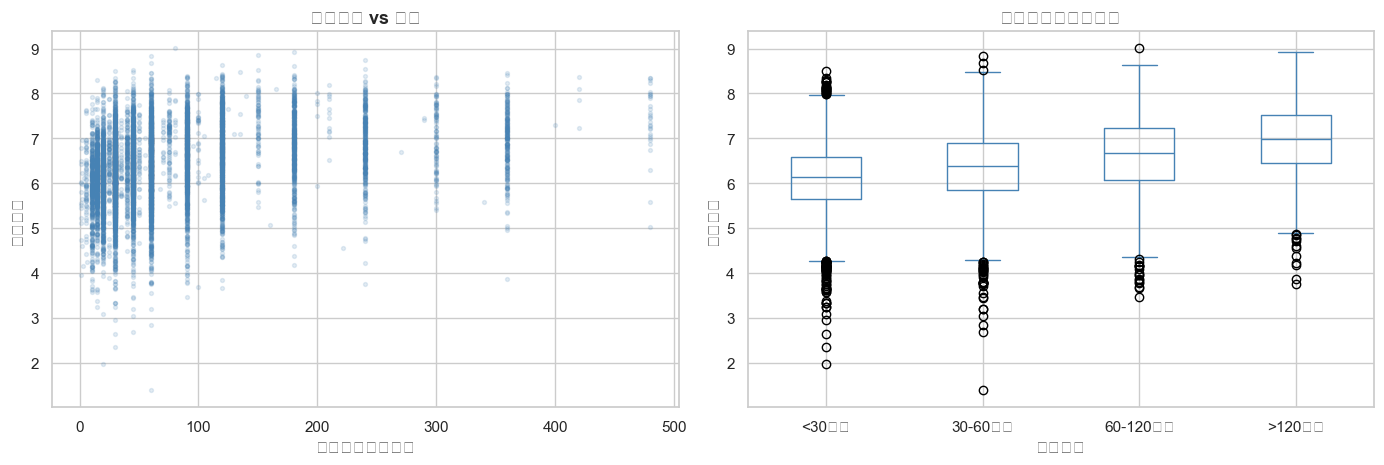

游戏时长 vs 评分 Pearson r = 0.058


In [4]:
# EDA 2：游戏时长 vs 评分
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 散点图
valid = df[df['playing_time'] < 500]
axes[0].scatter(valid['playing_time'], valid['average_rating'], alpha=0.15, s=8, color='steelblue')
axes[0].set_xlabel('游戏时长（分钟）')
axes[0].set_ylabel('平均评分')
axes[0].set_title('游戏时长 vs 评分', fontsize=13, fontweight='bold')

# 按时长分类的箱线图
df.boxplot(column='average_rating', by='time_bin', ax=axes[1], color='steelblue')
axes[1].set_title('各时长类别评分分布', fontsize=13, fontweight='bold')
axes[1].set_xlabel('时长类别')
axes[1].set_ylabel('平均评分')
plt.sca(axes[1])
plt.suptitle('')

plt.tight_layout()
plt.savefig('output/playing_time_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df[['playing_time', 'average_rating']].corr().iloc[0, 1]
print(f'游戏时长 vs 评分 Pearson r = {corr:.3f}')

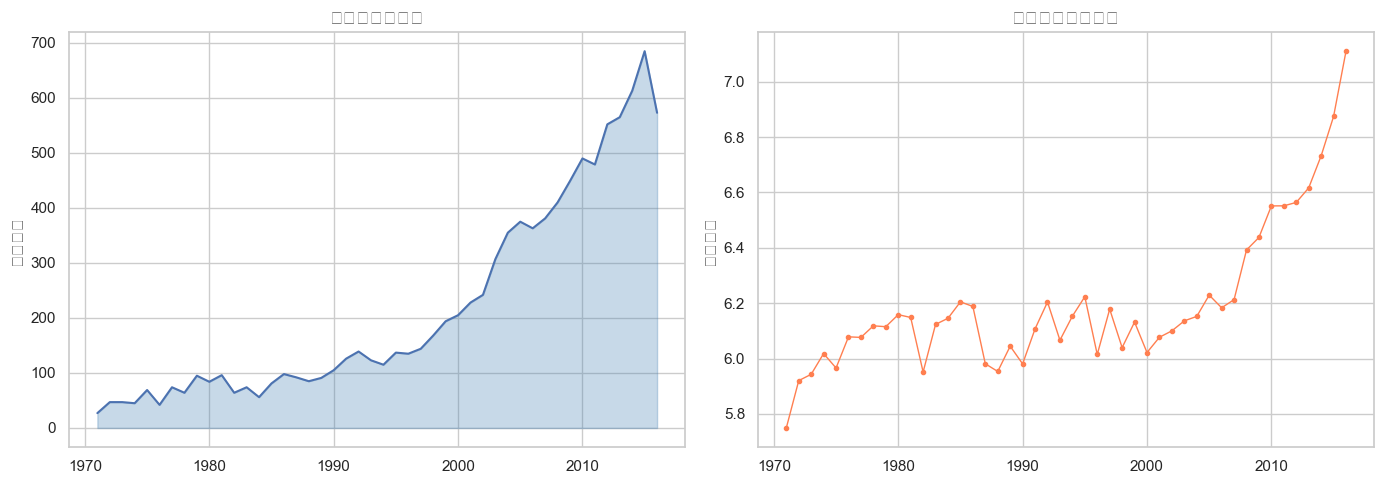

In [5]:
# EDA 3：年度趋势
yearly = df.groupby('year_published').agg(
    avg_rating=('average_rating', 'mean'),
    count=('average_rating', 'count'),
    avg_mechanics=('mechanics_count', 'mean')
).reset_index()
yearly = yearly[yearly['count'] >= 20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].fill_between(yearly['year_published'], yearly['count'], alpha=0.3, color='steelblue')
axes[0].plot(yearly['year_published'], yearly['count'], 'b-', linewidth=1.5)
axes[0].set_title('年度桌游发行量', fontsize=13, fontweight='bold')
axes[0].set_ylabel('发行数量')

axes[1].plot(yearly['year_published'], yearly['avg_rating'], 'o-', markersize=3, linewidth=1, color='coral')
axes[1].set_title('年度平均评分趋势', fontsize=13, fontweight='bold')
axes[1].set_ylabel('平均评分')

plt.tight_layout()
plt.savefig('output/yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

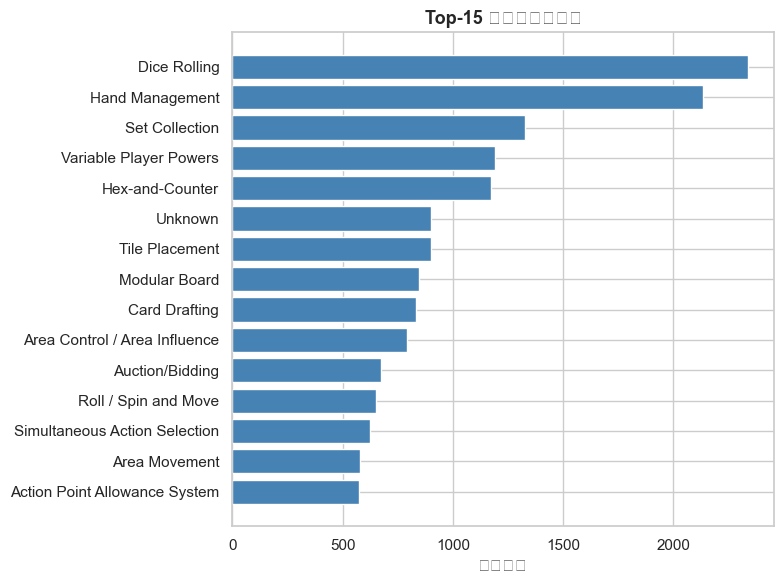

In [6]:
# EDA 4：热门机制
all_mechanics = df['mechanic'].dropna().str.split(',').explode().str.strip()
top_mechanics = all_mechanics.value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_mechanics.index.tolist()[::-1], top_mechanics.values.tolist()[::-1], color='steelblue')
ax.set_xlabel('游戏数量')
ax.set_title('Top-15 最热门桌游机制', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/top_mechanics.png', dpi=150, bbox_inches='tight')
plt.show()

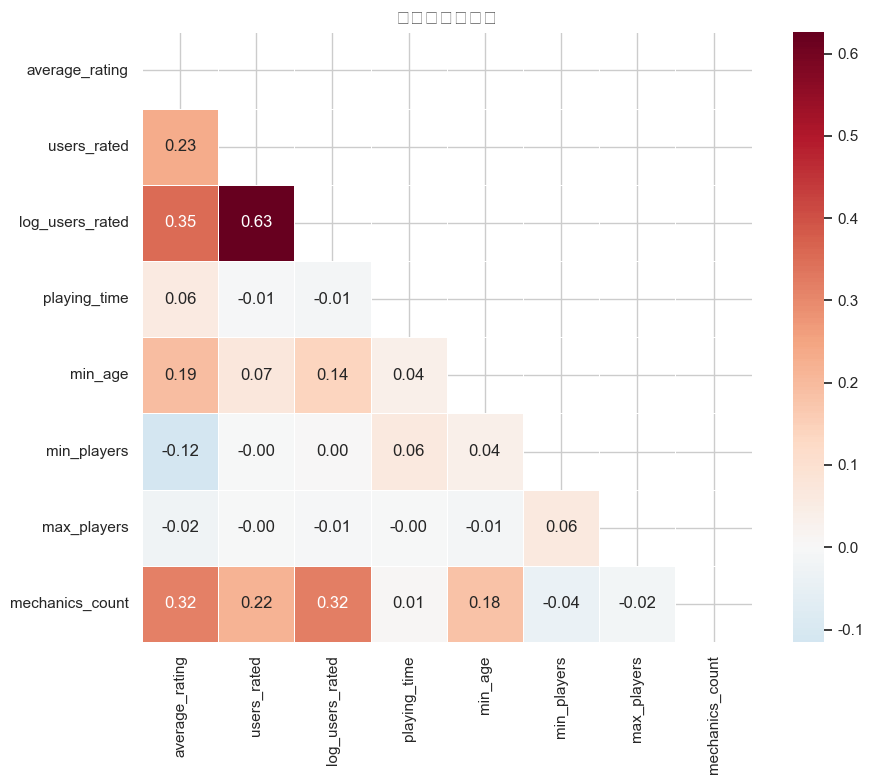

In [7]:
# EDA 5：相关性热力图
corr_cols = ['average_rating', 'users_rated', 'log_users_rated', 'playing_time',
             'min_age', 'min_players', 'max_players', 'mechanics_count']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('特征相关性矩阵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

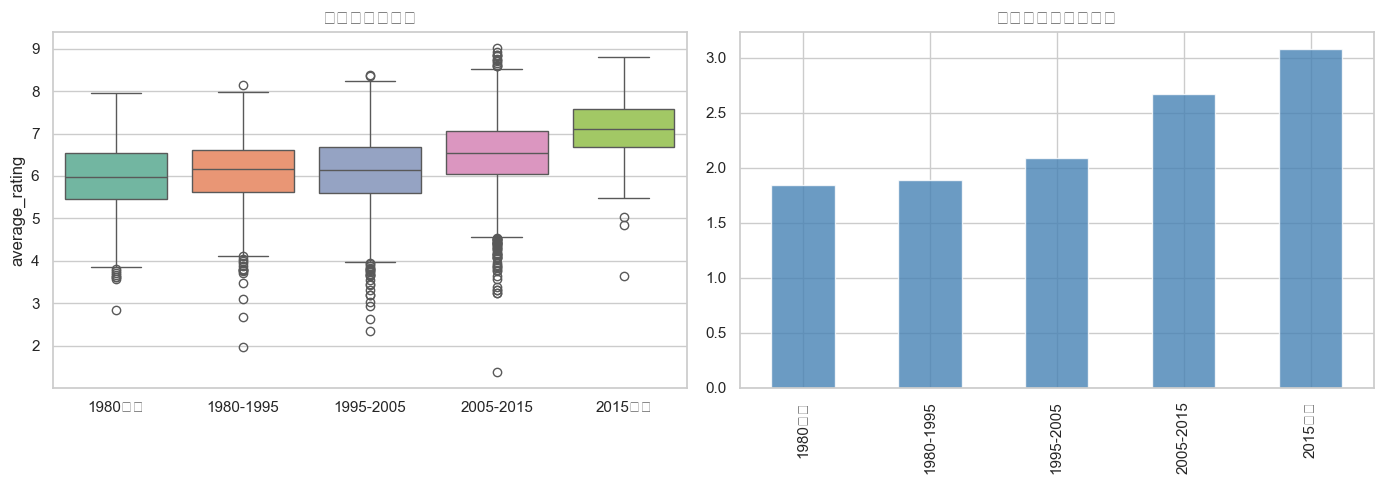

In [8]:
# 时代对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='era', y='average_rating', ax=axes[0], palette='Set2')
axes[0].set_title('各时代评分分布', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')

era_mech = df.groupby('era', observed=True)['mechanics_count'].mean()
era_mech.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('各时代平均机制数量', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('output/era_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 核心发现

In [ ]:
corr_time = df[['playing_time', 'average_rating']].corr().iloc[0, 1]
print(f'游戏时长 vs 评分: r = {corr_time:.3f}')
print(f'没啥相关性，复杂度和评分基本没关系')

recent = df[df['year_published'] >= 2000]
print(f'\n行业增长: 2000年后发行 {len(recent):,}/{len(df):,} 款 ({len(recent)/len(df)*100:.0f}%)')

high_q = df[df['mechanics_count'] >= df['mechanics_count'].quantile(0.75)]
low_q = df[df['mechanics_count'] <= df['mechanics_count'].quantile(0.25)]
diff = high_q['average_rating'].mean() - low_q['average_rating'].mean()
print(f'机制多样性: 机制多的游戏均分 {high_q["average_rating"].mean():.2f}, 机制少的 {low_q["average_rating"].mean():.2f}')
print(f'差异 {diff:.2f}，有一定正相关')

for era_name in year_labels:
    era_df = df[df['era'] == era_name]
    if len(era_df) >= 10:
        print(f'\n{era_name}: {len(era_df):,}款, 均分={era_df["average_rating"].mean():.2f}, 均机制数={era_df["mechanics_count"].mean():.1f}')